In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the CSV file
df = pd.read_csv("C:/Users/kihoo/OneDrive/Desktop/Berkeley/295/project4.csv", encoding="latin1")

# Drop the 'Name' column and any columns with NaN values
df = df.drop(columns=['Name'])
df = df.dropna(axis=1)  # Drop columns with NaN values

# Identify categorical and numerical columns
categorical_features = ['Team', 'Nationality', 'Position', 'Preferred Foot']
numerical_features = ['Age', 'Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']

# Separate features and target variable
X = df.drop(columns=['Market Value'])
y = df['Market Value']

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(X[categorical_features])
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# Create a new dataframe with encoded features and numerical features
X_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names)
X_final = pd.concat([X_encoded, X[numerical_features]], axis=1)


In [12]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_final, y)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_final.columns


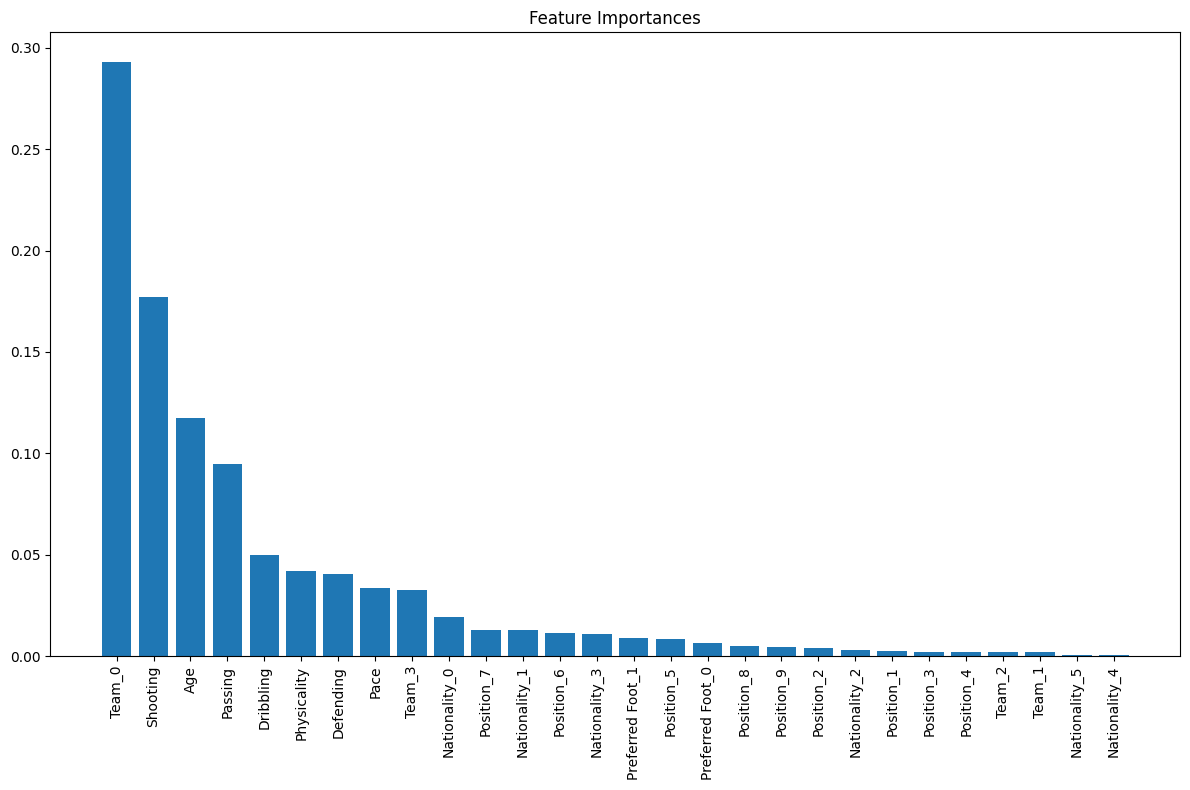

In [13]:
# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Create plot
plt.figure(figsize=(12, 8))
plt.title("Feature Importances")
plt.bar(range(X_final.shape[1]), importances[indices])
plt.xticks(range(X_final.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


In [15]:
# Identify numeric and categorical columns
numeric_features = ['Age', 'Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']
categorical_features = ['Team', 'Nationality', 'Position', 'Preferred Foot']

# Create preprocessing steps
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a preprocessing and model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Fit and transform the data
X_processed = pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [16]:
import keras
from keras import backend as K
from keras.layers import BatchNormalization

# Initialize weights with values between -0.1 and 0.1
initializer = keras.initializers.RandomUniform(minval=-0.1, maxval=0.1)

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]], kernel_initializer=initializer),
    BatchNormalization(),
    keras.layers.Dense(32, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    keras.layers.Dense(16, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),
    keras.layers.Dense(1, activation='linear', kernel_initializer=initializer)
])

model.summary()

c:\Users\kihoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,449 (17.38 KB)

 Non-trainable params: 224 (896.00 B)